# Fuzzy Logic Enhanced Decision Tree for SYN Flood Detection
## Explainable IoT Network Attack Detection

**Approach:** Instead of a plain binary decision tree, we use **fuzzy logic** with multi-attribute analysis:
- Each network attribute (SYN/ACK ratio, half-open connections, IP frequency, etc.) gets **fuzzy membership scores** (LOW/MEDIUM/HIGH)
- Fuzzy rules combine these memberships into a **confidence score** (0 to 1)
- The combined confidence provides **explainable, probabilistic detection**
- A Decision Tree trained on fuzzy features gives both accuracy AND interpretability

**Key Advantage:** Unlike binary classification, fuzzy logic provides nuanced "degrees of suspicion" - a packet can be 72% suspicious rather than just "attack" or "not attack".

In [33]:
# Section 1: Import Libraries and Load Dataset
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import skfuzzy as fuzz
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.tree import DecisionTreeClassifier, plot_tree, export_text
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, accuracy_score)
import warnings
warnings.filterwarnings('ignore')

# Prefer timeline-labeled dataset generated by label_attack_dataset.py
labeled_path = 'syn_udp_flood_attack_data_labeled.csv'
raw_path = 'syn_udp_flood_attack_data.csv'

if os.path.exists(labeled_path):
    dataset_path = labeled_path
else:
    dataset_path = raw_path

df = pd.read_csv(dataset_path)
print(f"Dataset loaded from: {dataset_path}")
print(f"Dataset loaded: {df.shape[0]} packets, {df.shape[1]} columns")

if 'attack' not in df.columns:
    raise ValueError(
        "Missing 'attack' column. Run label_attack_dataset.py first to create labeled ground truth. "
        "Example: .\\.venv\\Scripts\\python.exe label_attack_dataset.py --strict"
    )

# Normalize to binary 0/1
if not pd.api.types.is_numeric_dtype(df['attack']):
    mapped = df['attack'].astype(str).str.lower().map({
        'attack': 1, 'malicious': 1, 'anomaly': 1, '1': 1, 'true': 1,
        'normal': 0, 'benign': 0, '0': 0, 'false': 0
    })
    df['attack'] = mapped.fillna(0).astype(int)
else:
    df['attack'] = (df['attack'].astype(float) > 0).astype(int)

print(f"Attack distribution: {df['attack'].value_counts().to_dict()}")
print("\nRandom sample rows:")
display(df[['Time', 'Source', 'Destination', 'Protocol', 'Length', 'Info', 'attack']].sample(5, random_state=42))

Dataset loaded from: syn_udp_flood_attack_data_labeled.csv
Dataset loaded: 194792 packets, 9 columns
Attack distribution: {0: 165849, 1: 28943}

Random sample rows:


,Time,Source,Destination,Protocol,Length,Info,attack
84966,1742.637712,10.128.187.151,10.128.187.49,UDP,42,56406 > 53 Len=0,0
100907,1830.218870,10.128.187.151,10.128.187.49,TCP,54,"52397 > 80 [PSH, ACK] Seq=4036422410 Ack=106...",0
144882,1973.086412,10.128.187.49,10.128.187.151,ICMP,70,Destination unreachable (Port unreachable),0
174146,2036.832439,10.128.187.49,10.128.187.151,TCP,54,"80 > 59970 [RST, ACK] Seq=1 Ack=1 Win=0 Len=0",1
168297,2034.449310,10.128.187.151,10.128.187.49,TCP,54,[TCP Port numbers reused] 56421 > 80 [SYN] S...,1


In [34]:
# Base feature extraction (same as notebook 1)
import re

# Parse TCP flags
df['syn_flag'] = df['Info'].str.contains(r'\[SYN\]', regex=True, na=False).astype(int)
df['ack_flag'] = df['Info'].str.contains(r'\[ACK\]', regex=True, na=False).astype(int)
df['syn_ack_flag'] = df['Info'].str.contains(r'\[SYN, ACK\]', regex=True, na=False).astype(int)
df['fin_flag'] = df['Info'].str.contains(r'\[FIN', regex=True, na=False).astype(int)
df['is_retransmission'] = df['Info'].str.contains('Retransmission', na=False).astype(int)

# Protocol flags
df['is_modbus'] = (df['Protocol'] == 'Modbus/TCP').astype(int)
df['is_tcp'] = (df['Protocol'] == 'TCP').astype(int)

# Parse ports
def extract_ports(info):
    match = re.search(r'(\d+)\s+>\s+(\d+)', str(info))
    if match:
        return int(match.group(1)), int(match.group(2))
    return np.nan, np.nan

ports = df['Info'].apply(extract_ports)
df['src_port'] = ports.apply(lambda x: x[0])
df['dst_port'] = ports.apply(lambda x: x[1])

# Sort by time
df['Time'] = df['Time'].astype(float)
df = df.sort_values('Time').reset_index(drop=True)
df['time_delta'] = df['Time'].diff().fillna(0)
df['packet_length'] = df['Length'].astype(int)
df['is_syn_only'] = ((df['syn_flag'] == 1) & (df['syn_ack_flag'] == 0)).astype(int)

print(f"Base features extracted. Shape: {df.shape}")
print(f"SYN packets: {df['syn_flag'].sum()}, SYN-only (no ACK): {df['is_syn_only'].sum()}")

Base features extracted. Shape: (194792, 21)
SYN packets: 55104, SYN-only (no ACK): 55104


## Section 2: Feature Engineering for Fuzzy Attributes

We compute **7 fuzzy input attributes** that capture different behavioral dimensions of SYN flood attacks. Each attribute will later be mapped to fuzzy membership functions (LOW/MEDIUM/HIGH).

| Attribute | Description | Why it matters |
|-----------|-------------|----------------|
| `syn_ack_ratio` | SYN packets / ACK packets per source IP in window | Attackers send SYN but never ACK |
| `half_open_conn_count` | SYN sent without completing 3-way handshake | Core SYN flood signature |
| `same_src_ip_freq` | Packet frequency from same source IP in window | Spoofed IPs appear rarely then disappear |
| `syn_packet_density` | SYN packets per second in the network | Burst of SYNs = flood |
| `retransmission_rate` | Proportion of retransmitted packets in window | Attack SYNs get retransmitted |
| `unique_dst_port_count` | Unique destination ports from a source | Attackers may target specific port |
| `avg_time_between_syns` | Average inter-arrival time of SYN packets | Attack SYNs arrive in tight bursts |

In [35]:
# Section 2: Feature Engineering for Fuzzy Attributes
WINDOW = 50  # Rolling window size (packets)

# 1. SYN/ACK Ratio per source IP in rolling window
syn_window = df['syn_flag'].rolling(window=WINDOW, min_periods=1).sum()
ack_window = df['ack_flag'].rolling(window=WINDOW, min_periods=1).sum()
df['syn_ack_ratio'] = syn_window / (ack_window + 1)  # +1 to avoid division by zero

# 2. Half-open connection count (SYN without completing handshake)
df['half_open_conn_count'] = df['is_syn_only'].rolling(window=WINDOW, min_periods=1).sum()

# 3. Same source IP frequency in window
def rolling_src_freq(source_series, window):
    """For each packet, count how many times its source IP appears in the window."""
    result = []
    for i in range(len(source_series)):
        start = max(0, i - window + 1)
        window_slice = source_series.iloc[start:i+1]
        current_src = source_series.iloc[i]
        result.append((window_slice == current_src).sum() / len(window_slice))
    return result

df['same_src_ip_freq'] = rolling_src_freq(df['Source'], WINDOW)

# 4. SYN packet density (SYN packets per second in network)
window_time = df['Time'].rolling(window=WINDOW, min_periods=1).apply(
    lambda x: x.iloc[-1] - x.iloc[0], raw=False)
df['syn_packet_density'] = syn_window / (window_time.replace(0, np.nan))
df['syn_packet_density'] = df['syn_packet_density'].fillna(0).clip(upper=100)

# 5. Retransmission rate (proportion in window)
df['retransmission_rate'] = df['is_retransmission'].rolling(
    window=WINDOW, min_periods=1).mean()

# 6. Unique destination ports contacted by source in window
def rolling_unique_dst_ports(dst_port_series, window):
    result = []
    for i in range(len(dst_port_series)):
        start = max(0, i - window + 1)
        window_slice = dst_port_series.iloc[start:i+1].dropna()
        result.append(window_slice.nunique())
    return result

df['unique_dst_port_count'] = rolling_unique_dst_ports(df['dst_port'], WINDOW)

# 7. Average time between SYN packets from same source
def avg_syn_interarrival(df_input, window):
    """Compute average inter-arrival time of SYN packets in window."""
    result = []
    syn_times = []
    for i in range(len(df_input)):
        if df_input['syn_flag'].iloc[i] == 1:
            syn_times.append(df_input['Time'].iloc[i])
        # Keep only times within window
        start_idx = max(0, i - window + 1)
        start_time = df_input['Time'].iloc[start_idx]
        syn_times = [t for t in syn_times if t >= start_time]
        
        if len(syn_times) >= 2:
            diffs = np.diff(syn_times)
            result.append(np.mean(diffs))
        else:
            result.append(10.0)  # Large value = no SYN bursts
    return result

df['avg_time_between_syns'] = avg_syn_interarrival(df, WINDOW)

# Display stats for all fuzzy attributes
fuzzy_attrs = ['syn_ack_ratio', 'half_open_conn_count', 'same_src_ip_freq',
               'syn_packet_density', 'retransmission_rate', 'unique_dst_port_count',
               'avg_time_between_syns']

print("Fuzzy Attribute Statistics:")
print("=" * 70)
for attr in fuzzy_attrs:
    normal = df[df['attack']==0][attr]
    attack = df[df['attack']==1][attr]
    print(f"\n{attr}:")
    print(f"  Normal  -> mean: {normal.mean():.4f}, std: {normal.std():.4f}, "
          f"range: [{normal.min():.4f}, {normal.max():.4f}]")
    print(f"  Attack  -> mean: {attack.mean():.4f}, std: {attack.std():.4f}, "
          f"range: [{attack.min():.4f}, {attack.max():.4f}]")

Fuzzy Attribute Statistics:

syn_ack_ratio:
  Normal  -> mean: 13.3250, std: 12.3835, range: [0.0000, 37.0000]
  Attack  -> mean: 17.8472, std: 11.7109, range: [0.0000, 50.0000]

half_open_conn_count:
  Normal  -> mean: 13.4836, std: 12.3868, range: [0.0000, 37.0000]
  Attack  -> mean: 17.9305, std: 11.7028, range: [0.0000, 50.0000]

same_src_ip_freq:
  Normal  -> mean: 0.5484, std: 0.2116, range: [0.0200, 1.0000]
  Attack  -> mean: 0.5001, std: 0.0609, range: [0.0200, 1.0000]

syn_packet_density:
  Normal  -> mean: 52.3291, std: 48.6324, range: [0.0000, 100.0000]
  Attack  -> mean: 69.6455, std: 45.2257, range: [0.0000, 100.0000]

retransmission_rate:
  Normal  -> mean: 0.0008, std: 0.0073, range: [0.0000, 0.1800]
  Attack  -> mean: 0.0000, std: 0.0000, range: [0.0000, 0.0000]

unique_dst_port_count:
  Normal  -> mean: 18.2814, std: 11.2701, range: [0.0000, 41.0000]
  Attack  -> mean: 25.5419, std: 2.9074, range: [0.0000, 42.0000]

avg_time_between_syns:
  Normal  -> mean: 4.5164, std

## Section 3: Define Fuzzy Membership Functions

For each attribute, we define **triangular membership functions** for three linguistic variables:
- **LOW** - normal/benign range
- **MEDIUM** - ambiguous/borderline range
- **HIGH** - suspicious/attack-like range

Thresholds are derived from the data distributions above (domain knowledge + observed statistics).

Percentile-based normalization (2nd-98th percentile):
  syn_ack_ratio: clip=[0.0000, 27.0000] | Normal mean=0.492 | Attack mean=0.651
  half_open_conn_count: clip=[0.0000, 27.0000] | Normal mean=0.498 | Attack mean=0.654
  same_src_ip_freq: clip=[0.0600, 1.0000] | Normal mean=0.520 | Attack mean=0.468
  syn_packet_density: clip=[0.0000, 100.0000] | Normal mean=0.523 | Attack mean=0.696
  retransmission_rate: clip=[0.0000, 0.0000] | Normal mean=0.000 | Attack mean=0.000
  unique_dst_port_count: clip=[1.0000, 27.0000] | Normal mean=0.663 | Attack mean=0.939
  avg_time_between_syns: clip=[0.0001, 10.0000] | Normal mean=0.452 | Attack mean=0.289


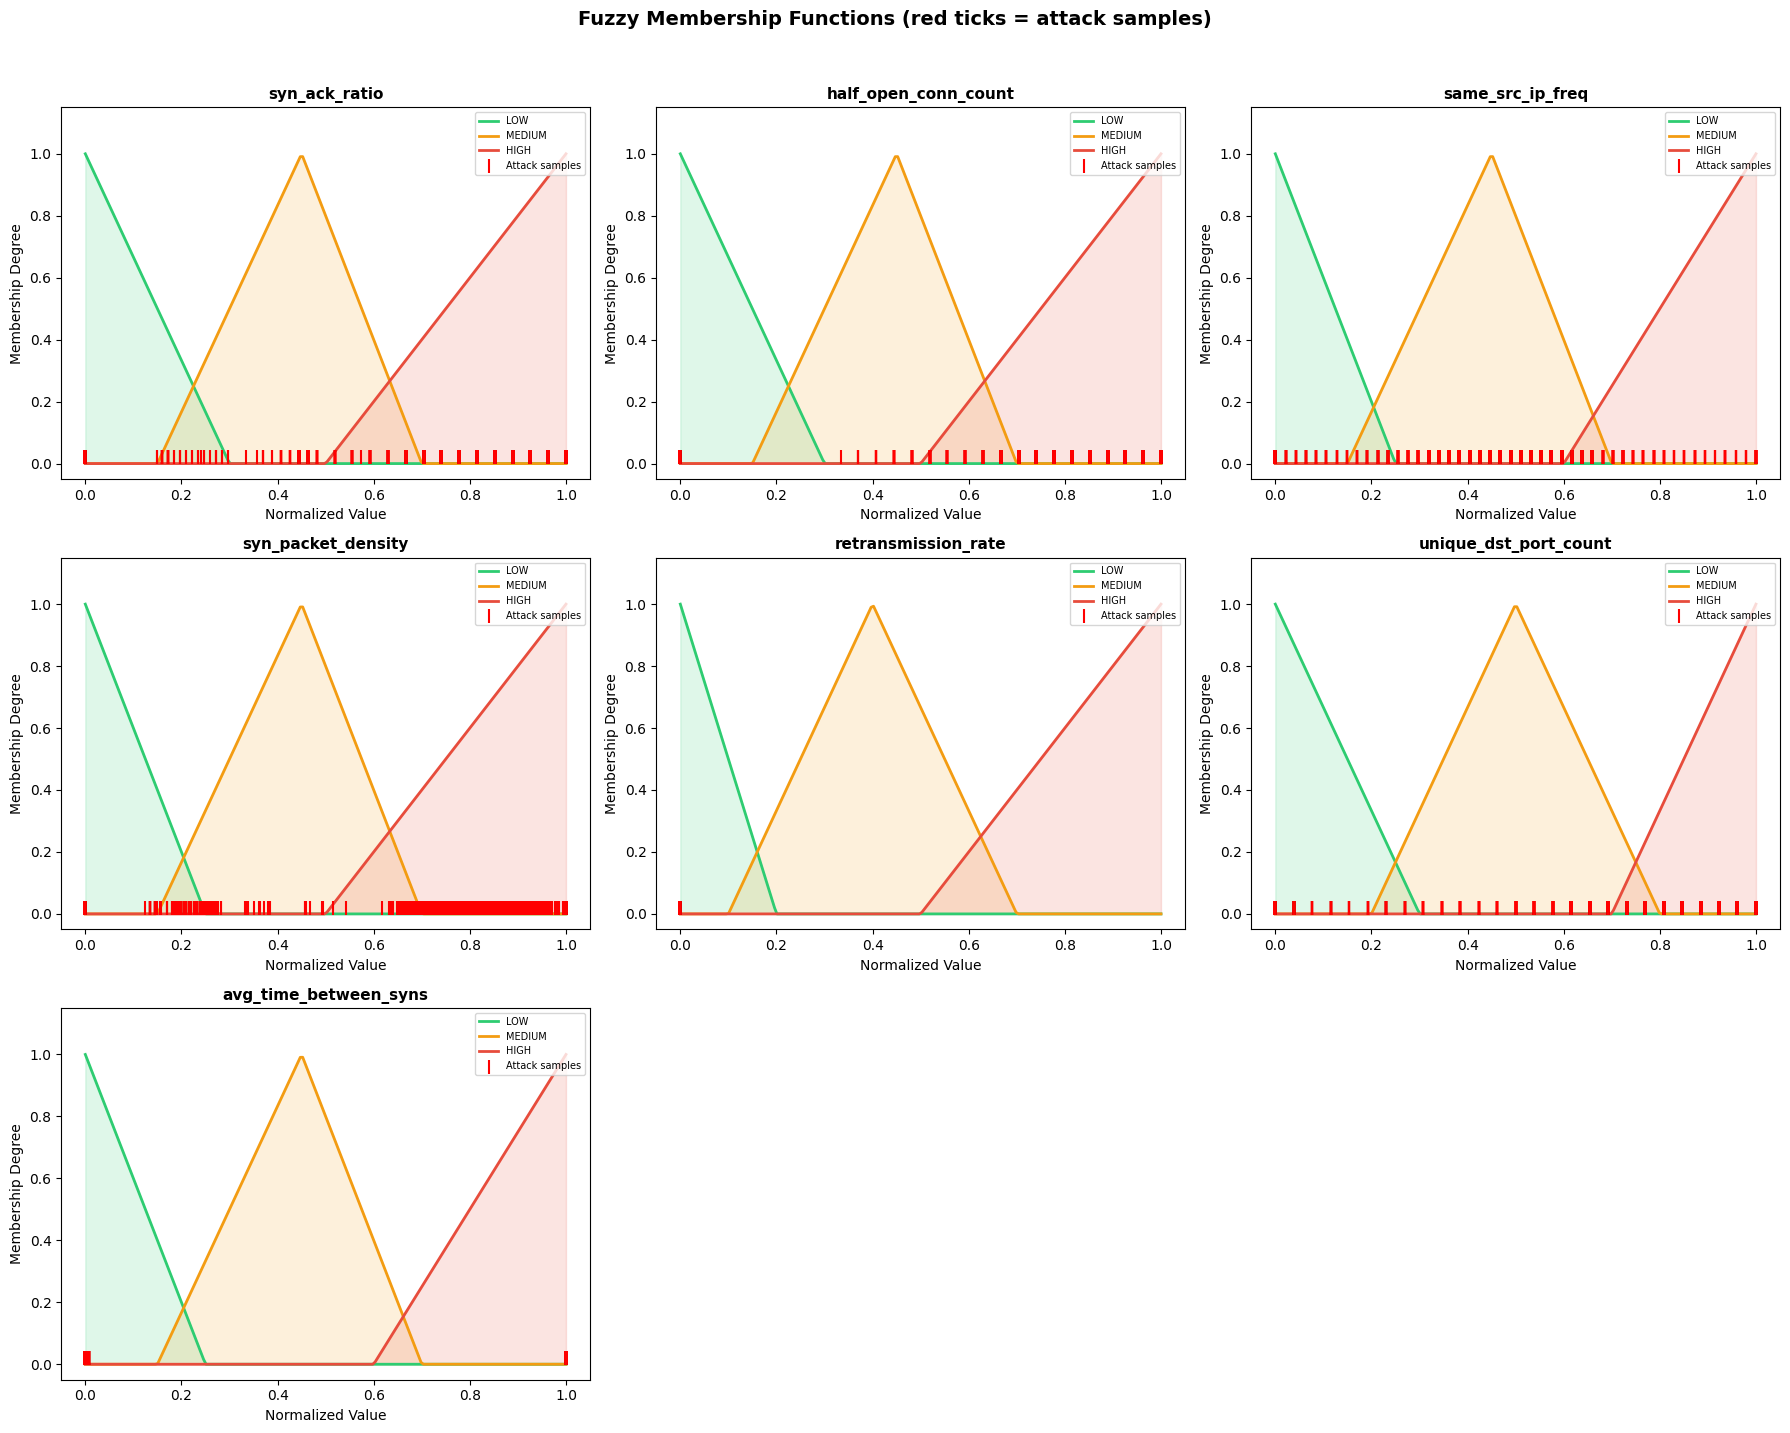

In [36]:
# Section 3: Define Fuzzy Membership Functions for Each Attribute
# Use percentile-based clipping (2nd-98th) to handle outliers before normalizing to [0,1]

fuzzy_normalized = pd.DataFrame(index=df.index)
clip_bounds = {}

for attr in fuzzy_attrs:
    values = df[attr].fillna(0)
    low_clip = values.quantile(0.02)
    high_clip = values.quantile(0.98)
    clipped = values.clip(lower=low_clip, upper=high_clip)
    range_val = high_clip - low_clip
    if range_val > 0:
        fuzzy_normalized[attr] = (clipped - low_clip) / range_val
    else:
        fuzzy_normalized[attr] = 0.0
    fuzzy_normalized[attr] = fuzzy_normalized[attr].clip(0, 1)
    clip_bounds[attr] = (low_clip, high_clip)

print("Percentile-based normalization (2nd-98th percentile):")
for attr in fuzzy_attrs:
    lo, hi = clip_bounds[attr]
    normal_norm = fuzzy_normalized.loc[df['attack']==0, attr]
    attack_norm = fuzzy_normalized.loc[df['attack']==1, attr]
    print(f"  {attr}: clip=[{lo:.4f}, {hi:.4f}] | "
          f"Normal mean={normal_norm.mean():.3f} | Attack mean={attack_norm.mean():.3f}")

# Define membership functions on the [0,1] normalized scale
membership_params = {
    'syn_ack_ratio': {
        'LOW':    [0.0, 0.0, 0.3],
        'MEDIUM': [0.15, 0.45, 0.7],
        'HIGH':   [0.5, 1.0, 1.0],
        'rationale': 'Attackers send SYN but never ACK - high SYN/ACK ratio'
    },
    'half_open_conn_count': {
        'LOW':    [0.0, 0.0, 0.3],
        'MEDIUM': [0.15, 0.45, 0.7],
        'HIGH':   [0.5, 1.0, 1.0],
        'rationale': 'SYN floods create many half-open connections'
    },
    'same_src_ip_freq': {
        'LOW':    [0.0, 0.0, 0.25],
        'MEDIUM': [0.15, 0.45, 0.7],
        'HIGH':   [0.6, 1.0, 1.0],
        'rationale': 'Spoofed IPs appear very rarely in window - LOW freq is suspicious'
    },
    'syn_packet_density': {
        'LOW':    [0.0, 0.0, 0.25],
        'MEDIUM': [0.15, 0.45, 0.7],
        'HIGH':   [0.5, 1.0, 1.0],
        'rationale': 'SYN floods generate bursts of SYN packets'
    },
    'retransmission_rate': {
        'LOW':    [0.0, 0.0, 0.2],
        'MEDIUM': [0.1, 0.4, 0.7],
        'HIGH':   [0.5, 1.0, 1.0],
        'rationale': 'Attack SYN packets get retransmitted under load'
    },
    'unique_dst_port_count': {
        'LOW':    [0.0, 0.0, 0.3],
        'MEDIUM': [0.2, 0.5, 0.8],
        'HIGH':   [0.7, 1.0, 1.0],
        'rationale': 'SYN floods target specific port (e.g., 502 for Modbus)'
    },
    'avg_time_between_syns': {
        'LOW':    [0.0, 0.0, 0.25],
        'MEDIUM': [0.15, 0.45, 0.7],
        'HIGH':   [0.6, 1.0, 1.0],
        'rationale': 'SYN floods show very short inter-arrival times'
    }
}

# Visualize membership functions with attack sample positions 
fig, axes = plt.subplots(3, 3, figsize=(18, 14))
axes = axes.flatten()

x_range = np.linspace(0, 1, 200)
colors = {'LOW': '#2ecc71', 'MEDIUM': '#f39c12', 'HIGH': '#e74c3c'}

for idx, attr in enumerate(fuzzy_attrs):
    ax = axes[idx]
    params = membership_params[attr]
    
    for level in ['LOW', 'MEDIUM', 'HIGH']:
        y = fuzz.trimf(x_range, params[level])
        ax.plot(x_range, y, color=colors[level], linewidth=2, label=level)
        ax.fill_between(x_range, y, alpha=0.15, color=colors[level])
    
    # Show where attack samples fall on the x-axis
    attack_vals = fuzzy_normalized.loc[df['attack']==1, attr]
    ax.scatter(attack_vals, [0.02]*len(attack_vals), color='red', marker='|', 
               s=100, zorder=5, label='Attack samples')
    
    ax.set_title(f'{attr}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Normalized Value')
    ax.set_ylabel('Membership Degree')
    ax.legend(loc='upper right', fontsize=7)
    ax.set_ylim(-0.05, 1.15)

for idx in range(len(fuzzy_attrs), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Fuzzy Membership Functions (red ticks = attack samples)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## Section 4: Compute Fuzzy Membership Scores per Observation

For each sample, we compute its **degree of membership** in LOW, MEDIUM, and HIGH for all 7 attributes, creating 21 new fuzzy features.

In [37]:
# Section 4: Compute Fuzzy Membership Scores per Observation
x_universe = np.linspace(0, 1, 200)

fuzzy_scores = pd.DataFrame(index=df.index)

for attr in fuzzy_attrs:
    params = membership_params[attr]
    values = fuzzy_normalized[attr].values
    
    for level in ['LOW', 'MEDIUM', 'HIGH']:
        col_name = f'{attr}_{level}'
        # Use interp_membership for each value
        scores = np.array([
            fuzz.interp_membership(x_universe, fuzz.trimf(x_universe, params[level]), v)
            for v in values
        ])
        fuzzy_scores[col_name] = scores

# Persist fuzzy scores in main dataframe for explainability and plotting sections
existing_fuzzy_cols = [c for c in fuzzy_scores.columns if c in df.columns]
if existing_fuzzy_cols:
    df = df.drop(columns=existing_fuzzy_cols)
df = pd.concat([df, fuzzy_scores], axis=1)

print(f"Fuzzy membership scores computed: {fuzzy_scores.shape[1]} features")
sample_cols = [f'{fuzzy_attrs[0]}_LOW', f'{fuzzy_attrs[0]}_MEDIUM', f'{fuzzy_attrs[0]}_HIGH']
print("\nSample fuzzy scores for NORMAL traffic (first 3):")
display(df[df['attack'] == 0][sample_cols].head(3))
print("\nSample fuzzy scores for ATTACK traffic (first 3):")
display(df[df['attack'] == 1][sample_cols].head(3))

Fuzzy membership scores computed: 21 features

Sample fuzzy scores for NORMAL traffic (first 3):


,syn_ack_ratio_LOW,syn_ack_ratio_MEDIUM,syn_ack_ratio_HIGH
0,1.0,0.0,0.0
1,1.0,0.0,0.0
2,1.0,0.0,0.0



Sample fuzzy scores for ATTACK traffic (first 3):


,syn_ack_ratio_LOW,syn_ack_ratio_MEDIUM,syn_ack_ratio_HIGH
157987,0.0,0.0,0.851852
157988,0.0,0.0,0.851852
157989,0.0,0.0,0.851852


## Section 5: Compute Combined Fuzzy Confidence Score

We define **fuzzy rules** based on domain knowledge of SYN flood attacks, then combine them into a single **attack confidence score** (0 to 1).

### Fuzzy Rules:
1. IF `syn_ack_ratio` is HIGH AND `half_open_conn` is HIGH → **Strong attack signal**
2. IF `syn_packet_density` is HIGH AND `avg_time_between_syns` is LOW → **Burst attack**
3. IF `same_src_ip_freq` is LOW AND `syn_ack_ratio` is HIGH → **Spoofed IP attack**
4. IF `retransmission_rate` is HIGH AND `half_open_conn` is HIGH → **Overwhelmed server**
5. IF `unique_dst_port_count` is LOW AND `syn_packet_density` is HIGH → **Targeted port flood**

Each rule produces a confidence value. The final score combines all rules using **weighted aggregation**.

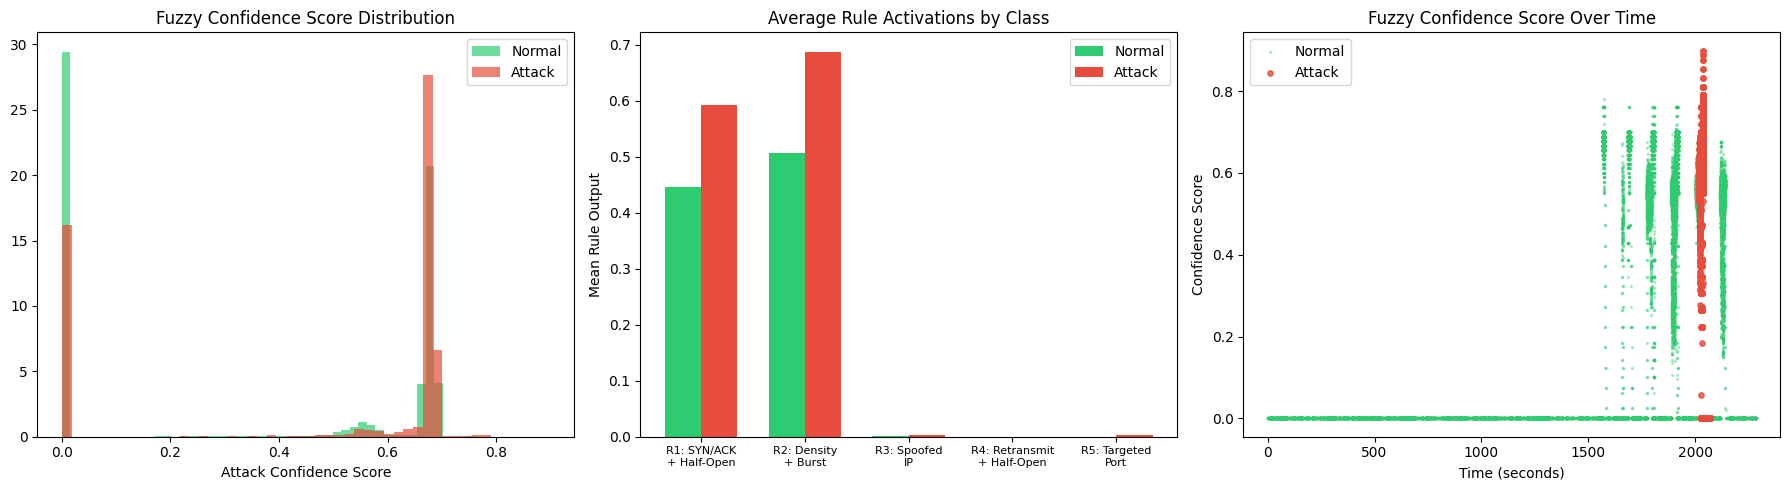

Threshold tuning is deferred to the training set to avoid leakage.

Fuzzy Confidence Statistics:
  Normal  - mean: 0.3525, max: 0.7798
  Attack  - mean: 0.4725, min: 0.0000


In [38]:
# Section 5: Compute Combined Fuzzy Confidence Score

def compute_fuzzy_rules(row):
    """Apply fuzzy rules and return individual rule confidences + combined score."""
    # Rule 1: High SYN/ACK ratio AND High half-open connections
    rule1 = min(row['syn_ack_ratio_HIGH'], row['half_open_conn_count_HIGH'])

    # Rule 2: High SYN density AND Low time between SYNs (burst)
    rule2 = min(row['syn_packet_density_HIGH'], row['avg_time_between_syns_LOW'])

    # Rule 3: Low source IP frequency (spoofed) AND High SYN/ACK ratio
    rule3 = min(row['same_src_ip_freq_LOW'], row['syn_ack_ratio_HIGH'])

    # Rule 4: High retransmission AND High half-open
    rule4 = min(row['retransmission_rate_HIGH'], row['half_open_conn_count_HIGH'])

    # Rule 5: Low destination port diversity AND High SYN density
    rule5 = min(row['unique_dst_port_count_LOW'], row['syn_packet_density_HIGH'])

    # Weighted aggregation
    weights = [0.25, 0.25, 0.20, 0.15, 0.15]
    rules = [rule1, rule2, rule3, rule4, rule5]
    combined = sum(w * r for w, r in zip(weights, rules))
    max_confidence = max(rules) if any(r > 0 for r in rules) else 0
    final_confidence = 0.6 * combined + 0.4 * max_confidence

    return pd.Series({
        'rule1_syn_ack_halfopen': rule1,
        'rule2_density_burst': rule2,
        'rule3_spoofed_ip': rule3,
        'rule4_retransmit_halfopen': rule4,
        'rule5_targeted_port': rule5,
        'fuzzy_confidence': final_confidence
    })

# Apply fuzzy rules to all observations
rule_results = fuzzy_scores.apply(compute_fuzzy_rules, axis=1)

# Merge into main dataframe (remove old columns if they exist from previous run)
for col in rule_results.columns:
    if col in df.columns:
        df.drop(col, axis=1, inplace=True)
df = pd.concat([df, rule_results], axis=1)

# Visualize confidence score distributions (threshold tuning will be done later on training set only)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confidence distribution by class
axes[0].hist(df[df['attack']==0]['fuzzy_confidence'], bins=50, alpha=0.7,
             color='#2ecc71', label='Normal', density=True)
axes[0].hist(df[df['attack']==1]['fuzzy_confidence'], bins=50, alpha=0.7,
             color='#e74c3c', label='Attack', density=True)
axes[0].set_title('Fuzzy Confidence Score Distribution')
axes[0].set_xlabel('Attack Confidence Score')
axes[0].legend()

# 2. Individual rule contributions (mean per class)
rule_cols = ['rule1_syn_ack_halfopen', 'rule2_density_burst', 'rule3_spoofed_ip',
             'rule4_retransmit_halfopen', 'rule5_targeted_port']
rule_names = ['R1: SYN/ACK\n+ Half-Open', 'R2: Density\n+ Burst', 'R3: Spoofed\nIP',
              'R4: Retransmit\n+ Half-Open', 'R5: Targeted\nPort']

normal_means = df[df['attack']==0][rule_cols].mean()
attack_means = df[df['attack']==1][rule_cols].mean()

x = np.arange(len(rule_names))
width = 0.35
axes[1].bar(x - width/2, normal_means, width, label='Normal', color='#2ecc71')
axes[1].bar(x + width/2, attack_means, width, label='Attack', color='#e74c3c')
axes[1].set_title('Average Rule Activations by Class')
axes[1].set_xticks(x)
axes[1].set_xticklabels(rule_names, fontsize=8)
axes[1].set_ylabel('Mean Rule Output')
axes[1].legend()

# 3. Confidence over time
axes[2].scatter(df[df['attack']==0]['Time'], df[df['attack']==0]['fuzzy_confidence'],
                alpha=0.3, s=2, c='#2ecc71', label='Normal')
axes[2].scatter(df[df['attack']==1]['Time'], df[df['attack']==1]['fuzzy_confidence'],
                alpha=0.8, s=15, c='#e74c3c', label='Attack')
axes[2].set_title('Fuzzy Confidence Score Over Time')
axes[2].set_xlabel('Time (seconds)')
axes[2].set_ylabel('Confidence Score')
axes[2].legend()

plt.tight_layout()
plt.show()

print("Threshold tuning is deferred to the training set to avoid leakage.")
print(f"\nFuzzy Confidence Statistics:")
print(f"  Normal  - mean: {df[df['attack']==0]['fuzzy_confidence'].mean():.4f}, "
      f"max: {df[df['attack']==0]['fuzzy_confidence'].max():.4f}")
print(f"  Attack  - mean: {df[df['attack']==1]['fuzzy_confidence'].mean():.4f}, "
      f"min: {df[df['attack']==1]['fuzzy_confidence'].min():.4f}")

## Section 6: Fuzzy Decision Tree Classification (Leakage-Aware)

We build two models using a chronological split to reduce leakage from adjacent packets:
1. **Threshold-based classifier** - Uses fuzzy confidence with threshold tuned on training data only
2. **Fuzzy-augmented Decision Tree** - Uses reduced, behavior-focused features + fuzzy rule outputs

In [39]:
# Section 6: Fuzzy Decision Tree Classification (Leakage-Aware)
from sklearn.metrics import f1_score as f1_calc
from sklearn.model_selection import train_test_split

# --- Feature sets (bloat-reduced) ---
original_features = [
    'packet_length', 'time_delta', 'is_syn_only',
    'syn_ack_ratio', 'half_open_conn_count', 'same_src_ip_freq',
    'syn_packet_density', 'retransmission_rate', 'unique_dst_port_count',
    'avg_time_between_syns'
 ]

rule_output_cols = [
    'rule1_syn_ack_halfopen', 'rule2_density_burst',
    'rule3_spoofed_ip', 'rule4_retransmit_halfopen',
    'rule5_targeted_port', 'fuzzy_confidence'
 ]

fuzzy_dt_features = original_features + rule_output_cols

y = df['attack'].astype(int)
X_fuzzy = df[fuzzy_dt_features].fillna(0)

# --- Split strategy ---
# Previous chronological split created severe train/test drift on this dataset.
# Use scenario-aware stratification when label_scenario exists; otherwise fallback to chronological split.
split_strategy = 'chronological-fallback'

def find_valid_time_split(labels, low=0.60, high=0.90, steps=31):
    n = len(labels)
    for frac in np.linspace(low, high, steps):
        idx = int(n * frac)
        y_left = labels.iloc[:idx]
        y_right = labels.iloc[idx:]
        if y_left.nunique() == 2 and y_right.nunique() == 2:
            return idx
    return int(n * 0.8)

if 'label_scenario' in df.columns and df['label_scenario'].notna().any():
    strat_key = np.where(
        y == 1,
        df['label_scenario'].astype(str),
        'normal_background'
    )
    train_idx, test_idx = train_test_split(
        df.index.values,
        test_size=0.2,
        random_state=42,
        stratify=strat_key
    )
    train_idx = np.sort(train_idx)
    test_idx = np.sort(test_idx)
    split_strategy = 'scenario-stratified-random'
else:
    split_idx = find_valid_time_split(y)
    train_idx = df.index.values[:split_idx]
    test_idx = df.index.values[split_idx:]

X_train, X_test = X_fuzzy.loc[train_idx].copy(), X_fuzzy.loc[test_idx].copy()
y_train, y_test = y.loc[train_idx].copy(), y.loc[test_idx].copy()

print(f"Feature set after bloat reduction: {len(fuzzy_dt_features)} features")
print(f"\nSplit strategy: {split_strategy}")
print(f"Train: {X_train.shape[0]} samples ({y_train.sum()} attacks)")
print(f"Test: {X_test.shape[0]} samples ({y_test.sum()} attacks)")
print(f"Train attack ratio: {y_train.mean():.4f} | Test attack ratio: {y_test.mean():.4f}")
if 'label_scenario' in df.columns:
    print("\nTrain scenarios:")
    print(df.loc[train_idx, 'label_scenario'].value_counts().head(8).to_string())
    print("\nTest scenarios:")
    print(df.loc[test_idx, 'label_scenario'].value_counts().head(8).to_string())

# --- Model 1: Threshold-based classifier (threshold from train only) ---
fuzzy_conf_train = df.loc[X_train.index, 'fuzzy_confidence']
fuzzy_conf_test = df.loc[X_test.index, 'fuzzy_confidence']

thresholds_to_try = np.linspace(0.0, 0.8, 161)
f1_scores_thresh = []
for t in thresholds_to_try:
    preds_train = (fuzzy_conf_train >= t).astype(int)
    f1_scores_thresh.append(f1_calc(y_train, preds_train))

optimal_threshold = thresholds_to_try[np.argmax(f1_scores_thresh)]
best_f1_thresh = max(f1_scores_thresh)
y_pred_threshold = (fuzzy_conf_test >= optimal_threshold).astype(int)

print(f"\nOptimal threshold (train-only tuning): {optimal_threshold:.4f} (Train F1={best_f1_thresh:.4f})")
print(f"\n{'='*60}")
print(f"MODEL 1: Fuzzy Threshold Classifier (confidence >= {optimal_threshold:.3f})")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_threshold, target_names=['Normal', 'Attack']))

# --- Model 2: Fuzzy-augmented Decision Tree with probability-threshold tuning ---
cv_splits = min(5, max(2, int(y_train.value_counts().min())))
cv = StratifiedKFold(n_splits=cv_splits, shuffle=True, random_state=42)
best_depth, best_f1 = None, -1

for depth in [3, 5, 7, 10, 15, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
    scores = cross_val_score(dt, X_train, y_train, cv=cv, scoring='f1')
    if scores.mean() > best_f1:
        best_f1 = scores.mean()
        best_depth = depth

fuzzy_dt = DecisionTreeClassifier(max_depth=best_depth, random_state=42, class_weight='balanced')
fuzzy_dt.fit(X_train, y_train)

y_proba_train_fuzzy_dt = fuzzy_dt.predict_proba(X_train)[:, 1]
y_pred_proba_fuzzy = fuzzy_dt.predict_proba(X_test)[:, 1]

dt_thresholds = np.linspace(0.05, 0.95, 181)
dt_train_f1_scores = [f1_calc(y_train, (y_proba_train_fuzzy_dt >= t).astype(int)) for t in dt_thresholds]
optimal_dt_threshold = dt_thresholds[int(np.argmax(dt_train_f1_scores))]
y_pred_fuzzy_dt = (y_pred_proba_fuzzy >= optimal_dt_threshold).astype(int)

print(f"\nBest DT depth by CV: {best_depth} (CV F1={best_f1:.4f})")
print(f"Optimal DT probability threshold (train-only): {optimal_dt_threshold:.3f}")
print(f"\n{'='*60}")
print(f"MODEL 2: Fuzzy-Augmented Decision Tree (max_depth={best_depth}, p>={optimal_dt_threshold:.3f})")
print(f"{'='*60}")
print(classification_report(y_test, y_pred_fuzzy_dt, target_names=['Normal', 'Attack']))

Feature set after bloat reduction: 16 features

Split strategy: scenario-stratified-random
Train: 155833 samples (23154 attacks)
Test: 38959 samples (5789 attacks)
Train attack ratio: 0.1486 | Test attack ratio: 0.1486

Train scenarios:
label_scenario
outside_logged_window    132642
Standard SYN Flood        16457
Standard UDP Flood         6697
Normal/Silence               37

Test scenarios:
label_scenario
outside_logged_window    33157
Standard SYN Flood        4115
Standard UDP Flood        1674
Normal/Silence              13

Optimal threshold (train-only tuning): 0.6000 (Train F1=0.3073)

MODEL 1: Fuzzy Threshold Classifier (confidence >= 0.600)
              precision    recall  f1-score   support

      Normal       0.90      0.54      0.68     33170
      Attack       0.20      0.66      0.31      5789

    accuracy                           0.56     38959
   macro avg       0.55      0.60      0.49     38959
weighted avg       0.80      0.56      0.62     38959


Best DT dept

## Section 7: Evaluate Fuzzy Decision Tree Model

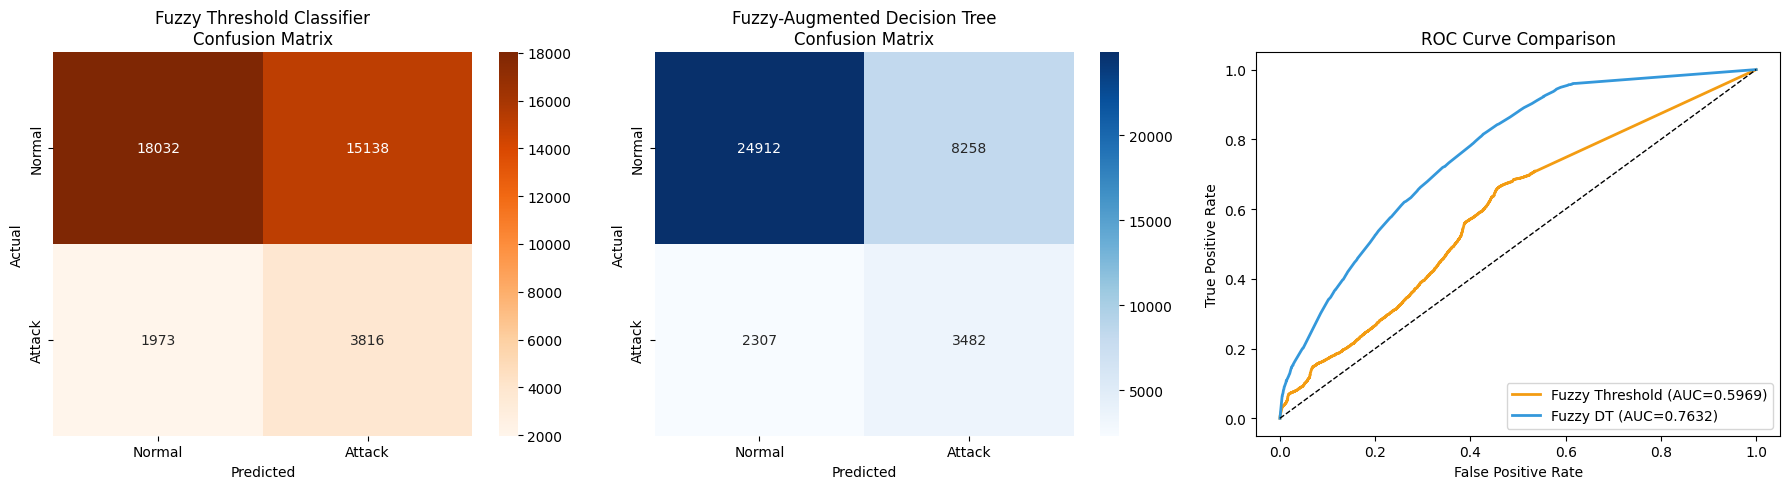


Fuzzy Threshold AUC: 0.5969
Fuzzy DT AUC: 0.7632
Fuzzy DT Train F1: 0.4087 | Test F1: 0.3973 | Gap: 0.0115
Dummy baseline Test Accuracy: 0.8514
No major overfitting signal from Fuzzy DT train-test F1 gap.


In [40]:
# Section 7: Evaluate Fuzzy Decision Tree Model
from sklearn.dummy import DummyClassifier
from sklearn.metrics import f1_score

y_pred_proba_fuzzy = fuzzy_dt.predict_proba(X_test)[:, 1]
y_pred_train_fuzzy_dt = fuzzy_dt.predict(X_train)

# Overfitting diagnostics
train_f1_dt = f1_score(y_train, y_pred_train_fuzzy_dt)
test_f1_dt = f1_score(y_test, y_pred_fuzzy_dt)
f1_gap_dt = train_f1_dt - test_f1_dt

# Baseline sanity check
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Confusion Matrix - Threshold classifier
cm_threshold = confusion_matrix(y_test, y_pred_threshold)
sns.heatmap(cm_threshold, annot=True, fmt='d', cmap='Oranges', ax=axes[0],
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
axes[0].set_title('Fuzzy Threshold Classifier\nConfusion Matrix')
axes[0].set_xlabel('Predicted')
axes[0].set_ylabel('Actual')

# 2. Confusion Matrix - Fuzzy DT
cm_fuzzy_dt = confusion_matrix(y_test, y_pred_fuzzy_dt)
sns.heatmap(cm_fuzzy_dt, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
axes[1].set_title('Fuzzy-Augmented Decision Tree\nConfusion Matrix')
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')

# 3. ROC curves comparison
fpr_thresh, tpr_thresh, _ = roc_curve(y_test, fuzzy_conf_test)
auc_thresh = roc_auc_score(y_test, fuzzy_conf_test)

fpr_dt, tpr_dt, _ = roc_curve(y_test, y_pred_proba_fuzzy)
auc_dt = roc_auc_score(y_test, y_pred_proba_fuzzy)

axes[2].plot(fpr_thresh, tpr_thresh, color='#f39c12', lw=2,
             label=f'Fuzzy Threshold (AUC={auc_thresh:.4f})')
axes[2].plot(fpr_dt, tpr_dt, color='#3498db', lw=2,
             label=f'Fuzzy DT (AUC={auc_dt:.4f})')
axes[2].plot([0, 1], [0, 1], 'k--', lw=1)
axes[2].set_title('ROC Curve Comparison')
axes[2].set_xlabel('False Positive Rate')
axes[2].set_ylabel('True Positive Rate')
axes[2].legend()

plt.tight_layout()
plt.show()

print(f"\nFuzzy Threshold AUC: {auc_thresh:.4f}")
print(f"Fuzzy DT AUC: {auc_dt:.4f}")
print(f"Fuzzy DT Train F1: {train_f1_dt:.4f} | Test F1: {test_f1_dt:.4f} | Gap: {f1_gap_dt:.4f}")
print(f"Dummy baseline Test Accuracy: {accuracy_score(y_test, dummy_pred):.4f}")

if f1_gap_dt > 0.10:
    print("Overfitting warning: Fuzzy DT has a notable train-test F1 gap.")
else:
    print("No major overfitting signal from Fuzzy DT train-test F1 gap.")

## Section 8: Explainability - Per-Sample Fuzzy Attribute Breakdown

This is the **key advantage** of the fuzzy approach: for any packet, we can explain *why* the model flagged it as an attack by showing which fuzzy attributes contributed most to the confidence score.

In [41]:
# Section 8: Explainability - Per-Sample Fuzzy Attribute Breakdown

def explain_prediction(df_row, idx, threshold):
    """Generate human-readable explanation for a single prediction."""
    confidence = df_row['fuzzy_confidence']
    actual = "ATTACK" if df_row['attack'] == 1 else "NORMAL"
    prediction = "ATTACK" if confidence >= threshold else "NORMAL"

    explanation = []
    explanation.append(f"{'='*65}")
    explanation.append(f"PACKET #{idx} | Source: {df_row['Source']} -> {df_row['Destination']}")
    explanation.append(f"Protocol: {df_row['Protocol']} | Time: {df_row['Time']:.4f}s")
    explanation.append(f"Actual: {actual} | Prediction: {prediction} | Threshold: {threshold:.3f}")
    explanation.append(f"Attack Confidence: {confidence:.4f}")
    explanation.append(f"{'-'*65}")

    # Show fuzzy attribute breakdown
    explanation.append("FUZZY ATTRIBUTE BREAKDOWN:")

    attr_names = {
        'syn_ack_ratio': 'SYN/ACK Ratio',
        'half_open_conn_count': 'Half-Open Connections',
        'same_src_ip_freq': 'Source IP Frequency',
        'syn_packet_density': 'SYN Packet Density',
        'retransmission_rate': 'Retransmission Rate',
        'unique_dst_port_count': 'Unique Dst Ports',
        'avg_time_between_syns': 'Avg Time Between SYNs'
    }

    for attr in fuzzy_attrs:
        low = df_row[f'{attr}_LOW']
        med = df_row[f'{attr}_MEDIUM']
        high = df_row[f'{attr}_HIGH']
        dominant = 'LOW' if low >= med and low >= high else ('MEDIUM' if med >= high else 'HIGH')
        dominant_val = max(low, med, high)
        bar = '#' * int(high * 20) + '.' * (20 - int(high * 20))
        explanation.append(f"  {attr_names[attr]:25s} -> {dominant:6s} ({dominant_val:.3f}) "
                          f"[L:{low:.2f} M:{med:.2f} H:{high:.2f}] {bar}")

    explanation.append(f"{'-'*65}")
    explanation.append("RULE ACTIVATIONS:")

    rules = {
        'rule1_syn_ack_halfopen': ('R1: High SYN/ACK + High Half-Open', 0.25),
        'rule2_density_burst': ('R2: High SYN Density + Low Inter-SYN Time', 0.25),
        'rule3_spoofed_ip': ('R3: Low Src IP Freq + High SYN/ACK (Spoofed)', 0.20),
        'rule4_retransmit_halfopen': ('R4: High Retransmission + High Half-Open', 0.15),
        'rule5_targeted_port': ('R5: Low Dst Port Diversity + High SYN Density', 0.15)
    }

    for rule_col, (desc, weight) in rules.items():
        val = df_row[rule_col]
        contribution = val * weight
        bar = '#' * int(val * 15) + '.' * (15 - int(val * 15))
        explanation.append(f"  {desc}")
        explanation.append(f"    Activation: {val:.3f} x Weight {weight:.2f} = "
                          f"Contribution: {contribution:.4f}  {bar}")

    explanation.append(f"{'='*65}")
    return '\n'.join(explanation)

# Show explanations for selected test samples
test_indices = X_test.index.tolist()

# Find attack/normal samples in the test split
attack_test = [i for i in test_indices if df.loc[i, 'attack'] == 1]
normal_test = [i for i in test_indices if df.loc[i, 'attack'] == 0]

print("=" * 66)
print("EXPLAINABLE FUZZY SYN FLOOD DETECTION RESULTS")
print("=" * 66)

# Show attack examples (or fallback to highest-confidence packets)
print("\nATTACK SAMPLES:")
attack_examples = attack_test[:2] if attack_test else list(df.loc[test_indices, 'fuzzy_confidence'].nlargest(2).index)
for idx in attack_examples:
    print(explain_prediction(df.loc[idx], idx, optimal_threshold))

# Show normal examples (or fallback to lowest-confidence packets)
print("\nNORMAL SAMPLES:")
normal_examples = normal_test[:2] if normal_test else list(df.loc[test_indices, 'fuzzy_confidence'].nsmallest(2).index)
for idx in normal_examples:
    print(explain_prediction(df.loc[idx], idx, optimal_threshold))

EXPLAINABLE FUZZY SYN FLOOD DETECTION RESULTS

ATTACK SAMPLES:
PACKET #157996 | Source: 10.128.187.49 -> 10.128.187.151
Protocol: TCP | Time: 2019.1597s
Actual: ATTACK | Prediction: NORMAL | Threshold: 0.600
Attack Confidence: 0.5730
-----------------------------------------------------------------
FUZZY ATTRIBUTE BREAKDOWN:
  SYN/ACK Ratio             -> HIGH   (0.852) [L:0.00 M:0.00 H:0.85] #################...
  Half-Open Connections     -> HIGH   (0.852) [L:0.00 M:0.00 H:0.85] #################...
  Source IP Frequency       -> MEDIUM (0.928) [L:0.00 M:0.93 H:0.00] ....................
  SYN Packet Density        -> HIGH   (0.696) [L:0.00 M:0.00 H:0.70] #############.......
  Retransmission Rate       -> LOW    (1.000) [L:1.00 M:0.00 H:0.00] ....................
  Unique Dst Ports          -> HIGH   (0.872) [L:0.00 M:0.00 H:0.87] #################...
  Avg Time Between SYNs     -> LOW    (0.995) [L:1.00 M:0.00 H:0.00] ....................
-------------------------------------------

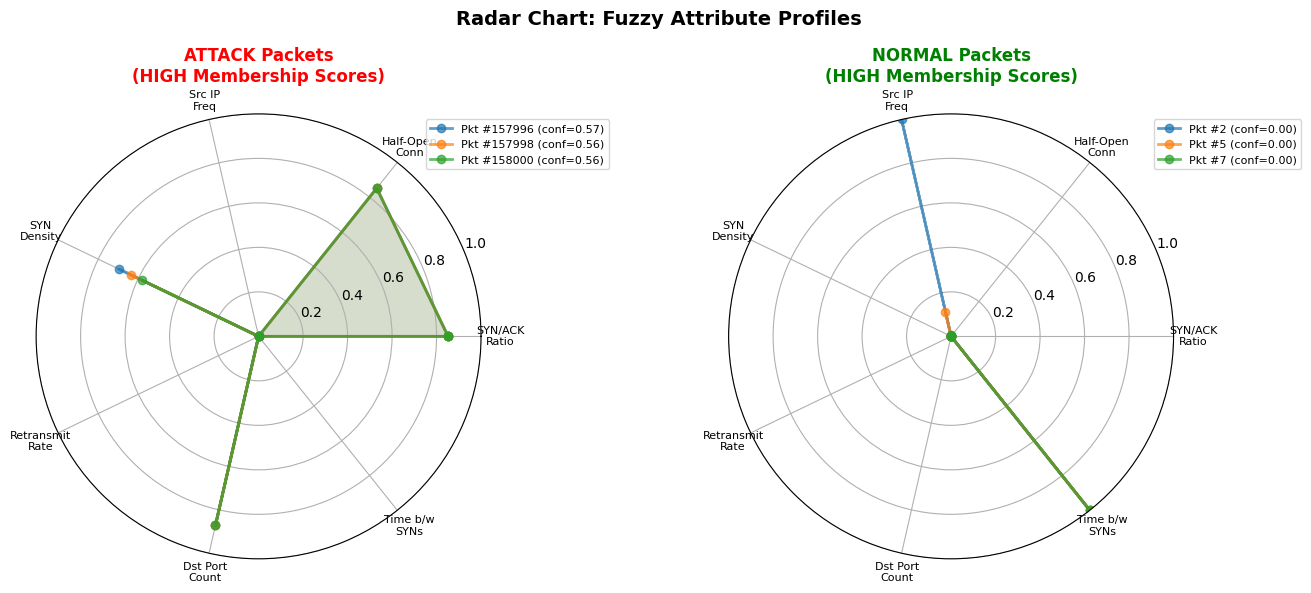

In [42]:
# Radar charts for attack vs normal samples
def plot_radar_comparison(df, attack_indices, normal_indices, fuzzy_attrs):
    """Plot radar charts comparing fuzzy HIGH membership scores."""
    labels = ['SYN/ACK\nRatio', 'Half-Open\nConn', 'Src IP\nFreq', 
              'SYN\nDensity', 'Retransmit\nRate', 'Dst Port\nCount', 
              'Time b/w\nSYNs']
    
    # Get HIGH membership values
    high_cols = [f'{attr}_HIGH' for attr in fuzzy_attrs]
    
    num_vars = len(labels)
    angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
    angles += angles[:1]  # Close the polygon
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 6), subplot_kw=dict(polar=True))
    
    attack_plot_indices = attack_indices[:3] if attack_indices else [df['fuzzy_confidence'].idxmax()]
    normal_plot_indices = normal_indices[:3] if normal_indices else [df['fuzzy_confidence'].idxmin()]
    
    # Attack samples radar
    for idx in attack_plot_indices:
        values = df.loc[idx, high_cols].values.tolist()
        values += values[:1]
        axes[0].plot(angles, values, 'o-', linewidth=2, alpha=0.7, 
                    label=f'Pkt #{idx} (conf={df.loc[idx,"fuzzy_confidence"]:.2f})')
        axes[0].fill(angles, values, alpha=0.1)
    
    axes[0].set_xticks(angles[:-1])
    axes[0].set_xticklabels(labels, fontsize=8)
    axes[0].set_title('ATTACK Packets\n(HIGH Membership Scores)', fontsize=12, fontweight='bold', color='red')
    axes[0].legend(loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)
    axes[0].set_ylim(0, 1)
    
    # Normal samples radar
    for idx in normal_plot_indices:
        values = df.loc[idx, high_cols].values.tolist()
        values += values[:1]
        axes[1].plot(angles, values, 'o-', linewidth=2, alpha=0.7,
                    label=f'Pkt #{idx} (conf={df.loc[idx,"fuzzy_confidence"]:.2f})')
        axes[1].fill(angles, values, alpha=0.1)
    
    axes[1].set_xticks(angles[:-1])
    axes[1].set_xticklabels(labels, fontsize=8)
    axes[1].set_title('NORMAL Packets\n(HIGH Membership Scores)', fontsize=12, fontweight='bold', color='green')
    axes[1].legend(loc='upper right', bbox_to_anchor=(1.3, 1), fontsize=8)
    axes[1].set_ylim(0, 1)
    
    plt.suptitle('Radar Chart: Fuzzy Attribute Profiles', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

plot_radar_comparison(df, attack_test, normal_test, fuzzy_attrs)

## Section 9: Explainability - Fuzzy Membership Distributions & Feature Importance

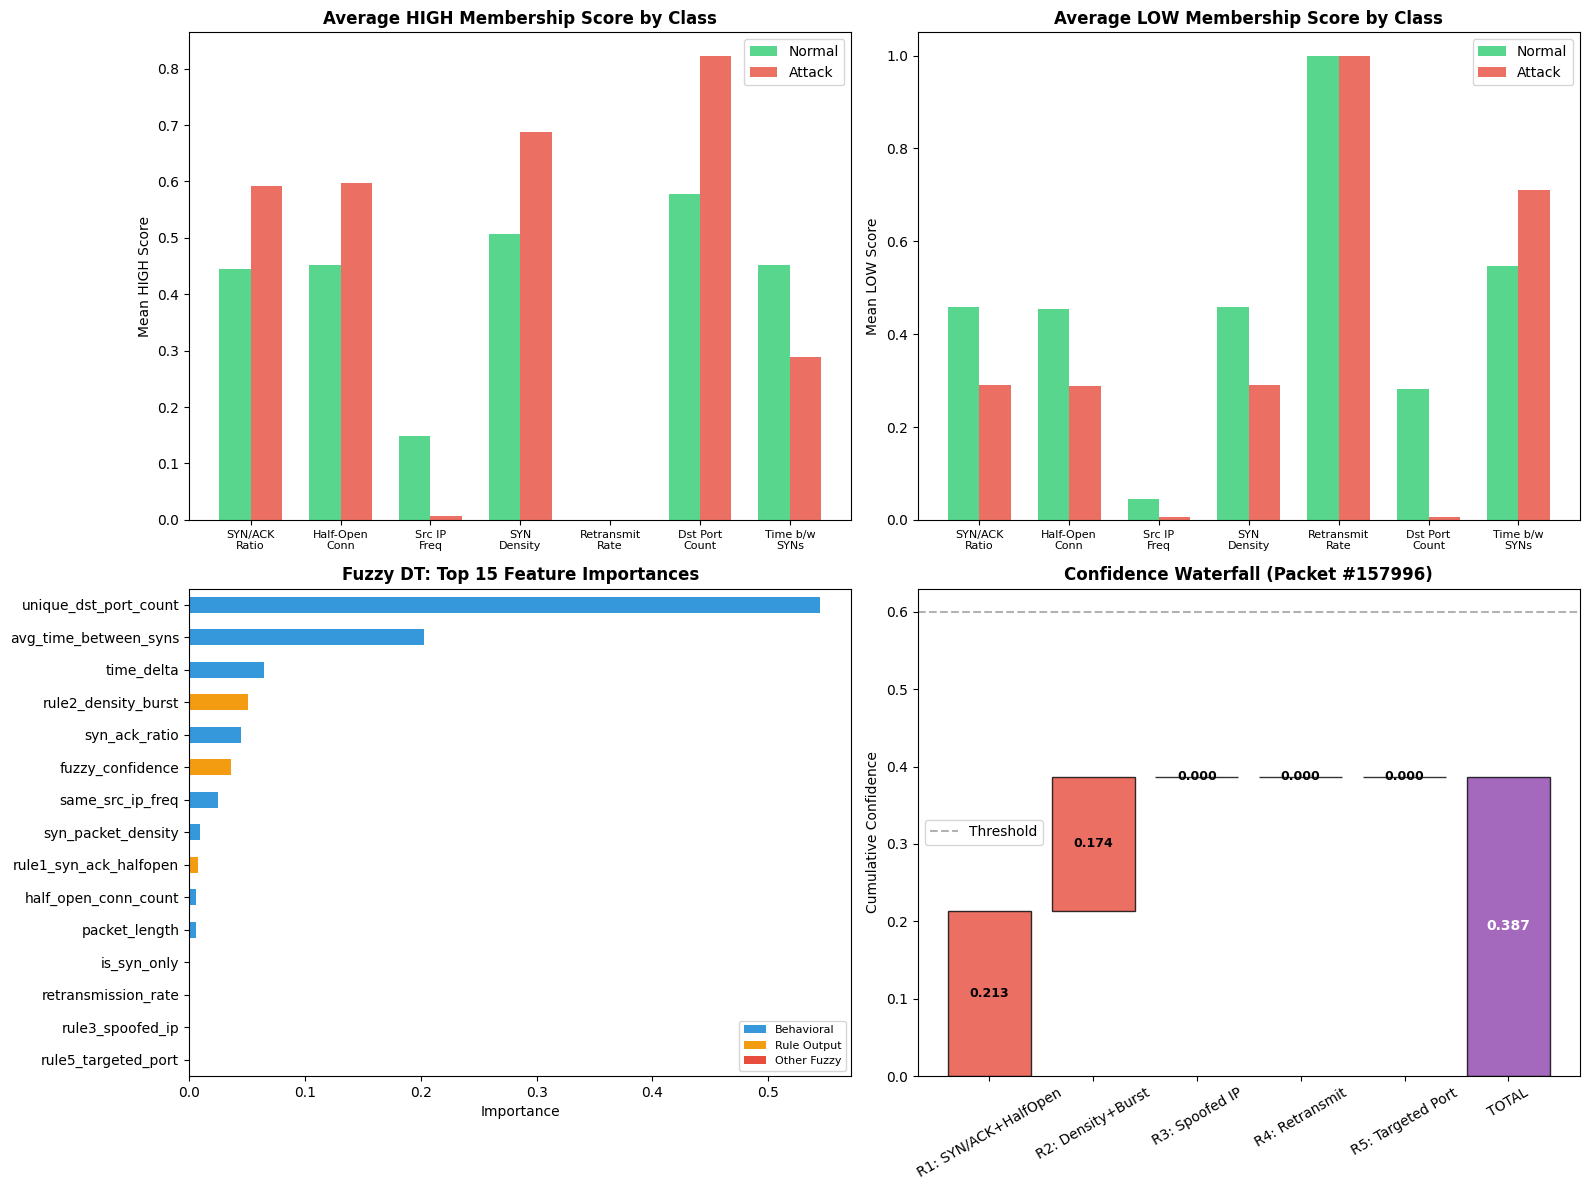

In [43]:
# Section 9: Explainability - Fuzzy Membership Distributions & Feature Importance

fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Average fuzzy HIGH scores: Normal vs Attack
high_cols = [f'{attr}_HIGH' for attr in fuzzy_attrs]
attr_labels = ['SYN/ACK\nRatio', 'Half-Open\nConn', 'Src IP\nFreq',
               'SYN\nDensity', 'Retransmit\nRate', 'Dst Port\nCount',
               'Time b/w\nSYNs']

normal_high = df[df['attack']==0][high_cols].mean()
attack_high = df[df['attack']==1][high_cols].mean()

x = np.arange(len(attr_labels))
width = 0.35
axes[0, 0].bar(x - width/2, normal_high, width, label='Normal', color='#2ecc71', alpha=0.8)
axes[0, 0].bar(x + width/2, attack_high, width, label='Attack', color='#e74c3c', alpha=0.8)
axes[0, 0].set_title('Average HIGH Membership Score by Class', fontweight='bold')
axes[0, 0].set_xticks(x)
axes[0, 0].set_xticklabels(attr_labels, fontsize=8)
axes[0, 0].set_ylabel('Mean HIGH Score')
axes[0, 0].legend()

# 2. Average fuzzy LOW scores: Normal vs Attack
low_cols = [f'{attr}_LOW' for attr in fuzzy_attrs]
normal_low = df[df['attack']==0][low_cols].mean()
attack_low = df[df['attack']==1][low_cols].mean()

axes[0, 1].bar(x - width/2, normal_low, width, label='Normal', color='#2ecc71', alpha=0.8)
axes[0, 1].bar(x + width/2, attack_low, width, label='Attack', color='#e74c3c', alpha=0.8)
axes[0, 1].set_title('Average LOW Membership Score by Class', fontweight='bold')
axes[0, 1].set_xticks(x)
axes[0, 1].set_xticklabels(attr_labels, fontsize=8)
axes[0, 1].set_ylabel('Mean LOW Score')
axes[0, 1].legend()

# 3. Fuzzy DT Feature Importances (top 15)
importances = pd.Series(fuzzy_dt.feature_importances_, index=fuzzy_dt_features)
top_features = importances.nlargest(15).sort_values()

colors = []
for feat in top_features.index:
    if feat in original_features:
        colors.append('#3498db')  # Blue for original behavioral
    elif feat in rule_output_cols:
        colors.append('#f39c12')  # Orange for rule outputs
    else:
        colors.append('#e74c3c')  # Red for other fuzzy-derived
top_features.plot(kind='barh', ax=axes[1, 0], color=colors)
axes[1, 0].set_title('Fuzzy DT: Top 15 Feature Importances', fontweight='bold')
axes[1, 0].set_xlabel('Importance')

# Legend
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#3498db', label='Behavioral'),
                   Patch(facecolor='#f39c12', label='Rule Output'),
                   Patch(facecolor='#e74c3c', label='Other Fuzzy')]
axes[1, 0].legend(handles=legend_elements, loc='lower right', fontsize=8)

# 4. Waterfall chart - how each fuzzy rule shifts confidence for one attack sample
sample_idx = attack_test[0] if attack_test else df[df['attack']==1].index[0]
sample = df.loc[sample_idx]

rule_contributions = {
    'R1: SYN/ACK+HalfOpen': sample['rule1_syn_ack_halfopen'] * 0.25,
    'R2: Density+Burst': sample['rule2_density_burst'] * 0.25,
    'R3: Spoofed IP': sample['rule3_spoofed_ip'] * 0.20,
    'R4: Retransmit': sample['rule4_retransmit_halfopen'] * 0.15,
    'R5: Targeted Port': sample['rule5_targeted_port'] * 0.15,
}

names = list(rule_contributions.keys()) + ['TOTAL']
values = list(rule_contributions.values())
cumulative = np.cumsum(values)
total = sum(values)

bar_colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in values]
bar_bottoms = [0] + cumulative[:-1].tolist()

axes[1, 1].bar(names[:-1], values, bottom=bar_bottoms, color=bar_colors, alpha=0.8, edgecolor='black')
axes[1, 1].bar('TOTAL', total, color='#8e44ad', alpha=0.8, edgecolor='black')

for i, (name, val, bottom) in enumerate(zip(names[:-1], values, bar_bottoms)):
    axes[1, 1].text(i, bottom + val/2, f'{val:.3f}', ha='center', va='center', fontsize=9, fontweight='bold')
axes[1, 1].text(len(values), total/2, f'{total:.3f}', ha='center', va='center',
                fontsize=10, fontweight='bold', color='white')

axes[1, 1].set_title(f'Confidence Waterfall (Packet #{sample_idx})', fontweight='bold')
axes[1, 1].set_ylabel('Cumulative Confidence')
axes[1, 1].tick_params(axis='x', rotation=30)
axes[1, 1].axhline(y=optimal_threshold, color='black', linestyle='--', alpha=0.3, label='Threshold')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

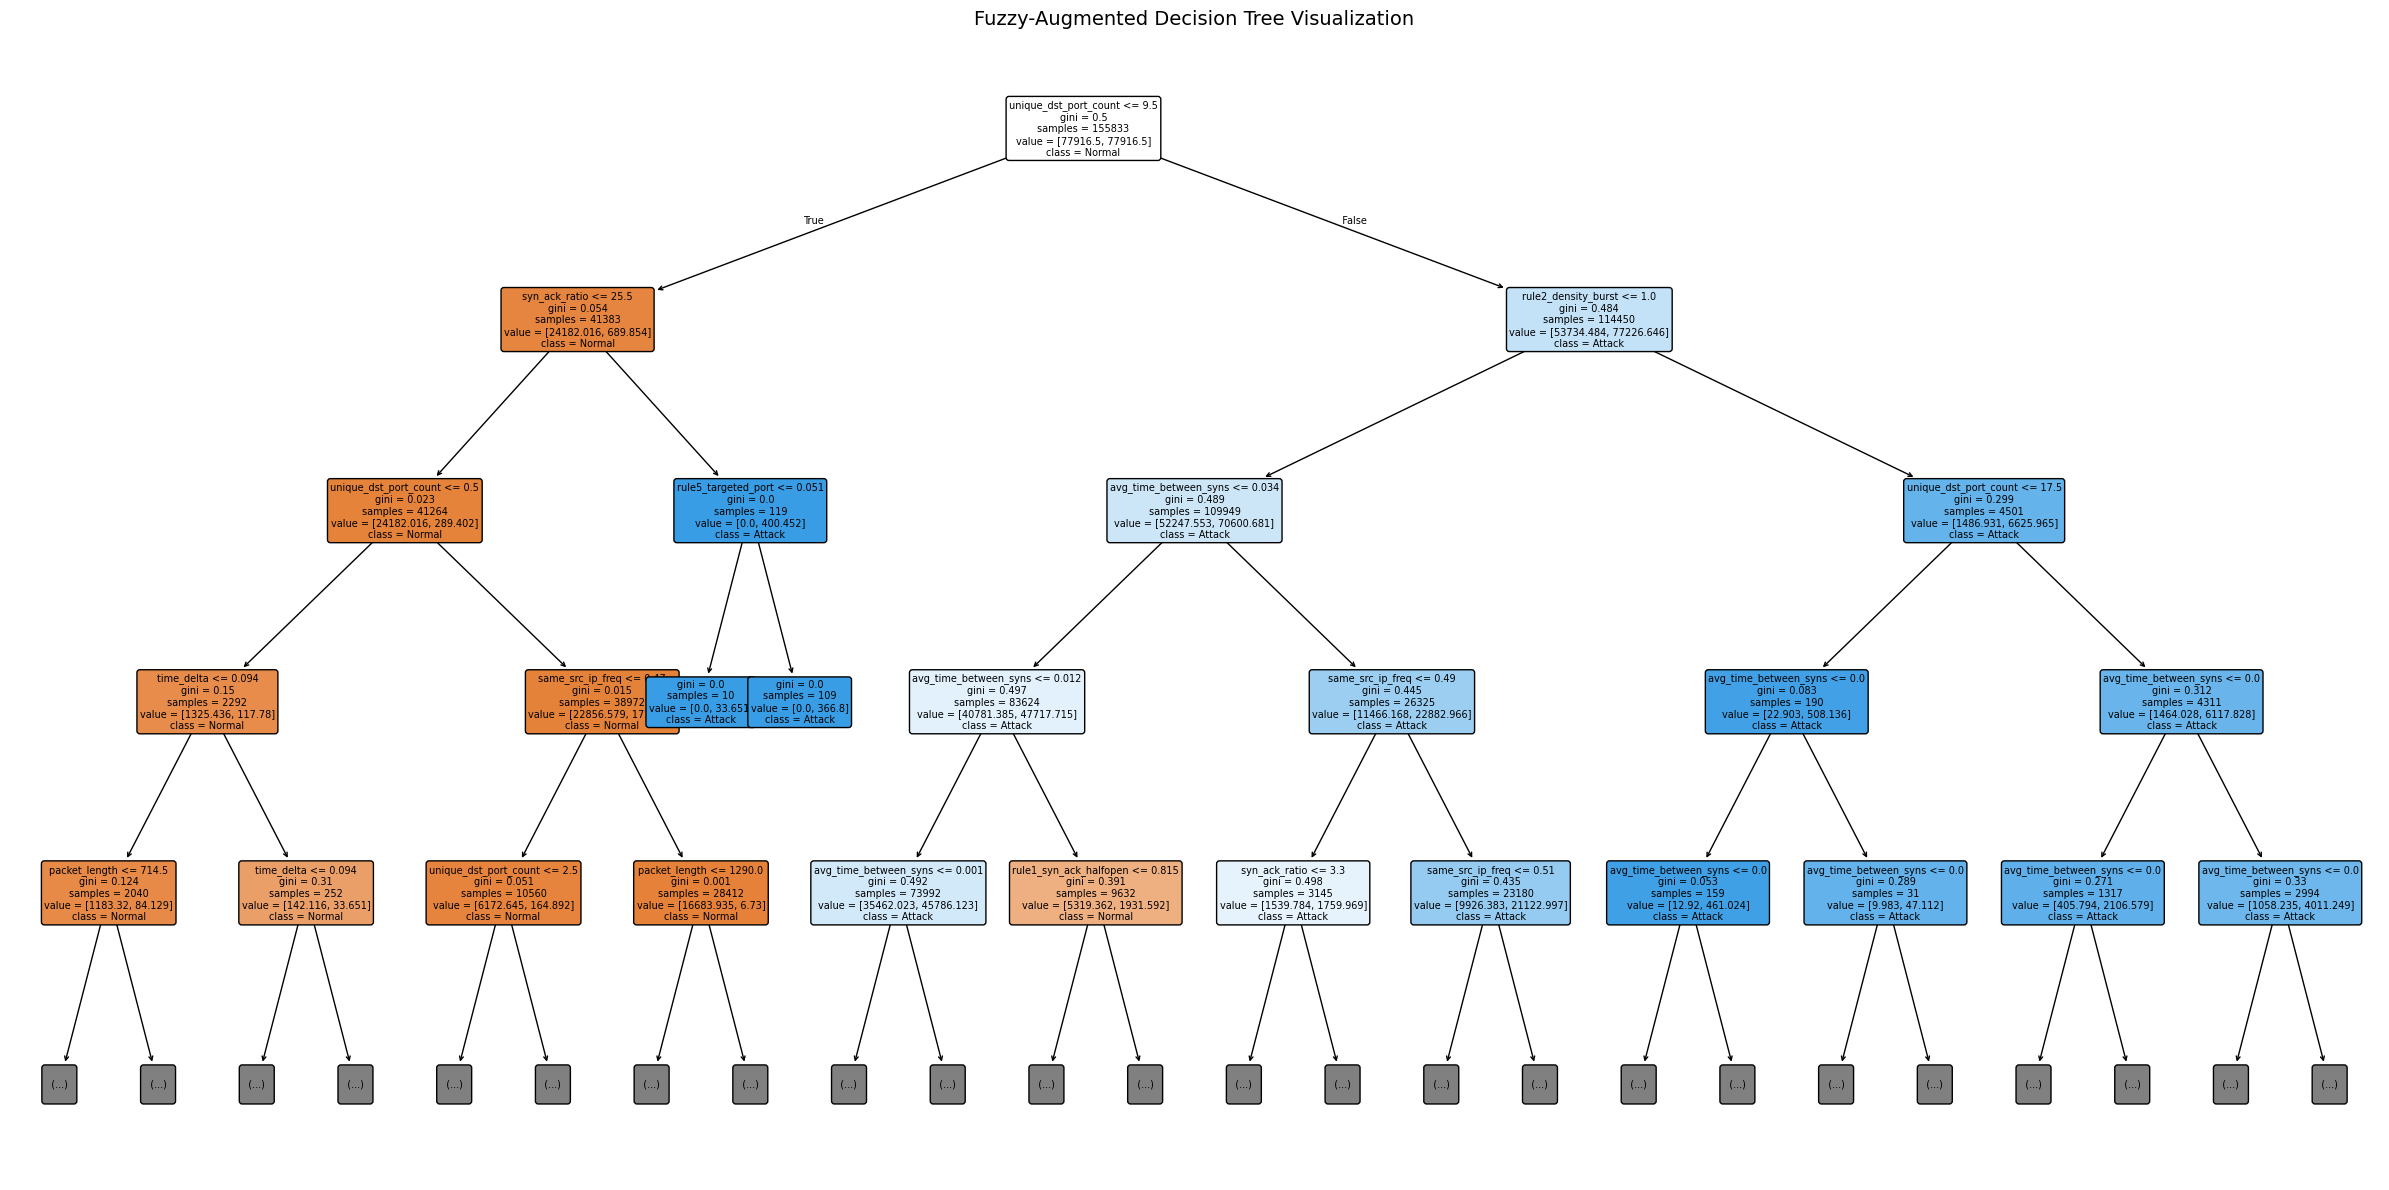


Fuzzy Decision Tree Rules:
|--- unique_dst_port_count <= 9.50
|   |--- syn_ack_ratio <= 25.50
|   |   |--- unique_dst_port_count <= 0.50
|   |   |   |--- time_delta <= 0.09
|   |   |   |   |--- packet_length <= 714.50
|   |   |   |   |   |--- packet_length <= 701.50
|   |   |   |   |   |   |--- truncated branch of depth 10
|   |   |   |   |   |--- packet_length >  701.50
|   |   |   |   |   |   |--- class: 1
|   |   |   |   |--- packet_length >  714.50
|   |   |   |   |   |--- same_src_ip_freq <= 0.17
|   |   |   |   |   |   |--- truncated branch of depth 6
|   |   |   |   |   |--- same_src_ip_freq >  0.17
|   |   |   |   |   |   |--- class: 0
|   |   |   |--- time_delta >  0.09
|   |   |   |   |--- time_delta <= 0.09
|   |   |   |   |   |--- class: 1
|   |   |   |   |--- time_delta >  0.09
|   |   |   |   |   |--- same_src_ip_freq <= 0.07
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- same_src_ip_freq >  0.07
|   |   |   |   |   |   |--- truncated branch of depth 10
|

In [44]:
# Visualize the Fuzzy Decision Tree
_, ax = plt.subplots(figsize=(24, 12))
plot_tree(fuzzy_dt, feature_names=fuzzy_dt_features, class_names=['Normal', 'Attack'],
          filled=True, rounded=True, ax=ax, fontsize=7, max_depth=4)
ax.set_title('Fuzzy-Augmented Decision Tree Visualization', fontsize=14)
plt.tight_layout()
plt.show()

# Print tree rules
print("\nFuzzy Decision Tree Rules:")
print("=" * 60)
print(export_text(fuzzy_dt, feature_names=fuzzy_dt_features, max_depth=5))

## Section 10: Comparison - Standard Decision Tree vs Fuzzy Decision Tree

MODEL COMPARISON: Standard DT vs Fuzzy Approaches (improved split + threshold tuning)
                        Standard DT                  Fuzzy Threshold                   Fuzzy DT
Accuracy                     0.6762                           0.5608                     0.7288
Precision                    0.2934                           0.2013                     0.2966
Recall                       0.6252                           0.6592                     0.6015
F1-Score                     0.3993                           0.3085                     0.3973
AUC                          0.7661                           0.5969                     0.7632
Explainability  Medium (tree rules)  High (confidence score + rules)  High (fuzzy rules + tree)

Standard DT optimal probability threshold: 0.600
Fuzzy DT optimal probability threshold: 0.615
Dummy baseline accuracy: 0.8514


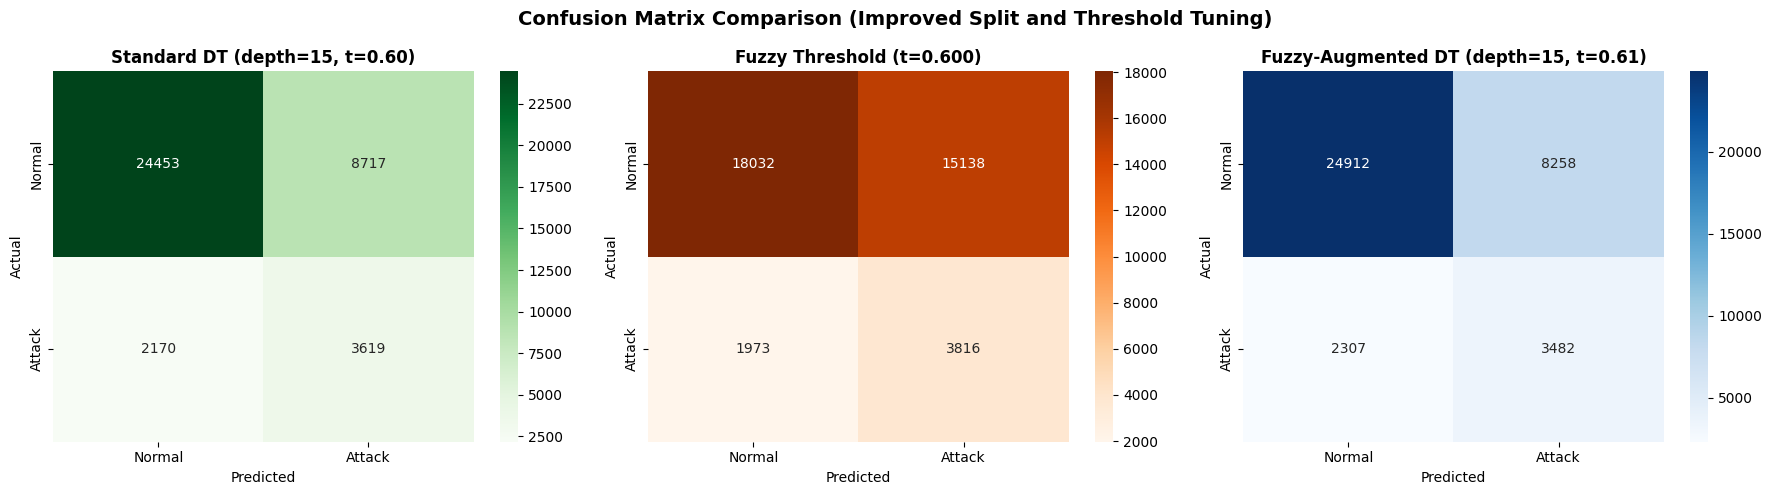

In [ ]:
# Section 10: Comparison - Standard DT vs Fuzzy DT (same split strategy as Section 6)
from sklearn.metrics import precision_score, recall_score
from sklearn.dummy import DummyClassifier

# Standard DT uses the same reduced behavioral features for fair comparison
std_features = [
    'packet_length', 'time_delta', 'is_syn_only',
    'syn_ack_ratio', 'half_open_conn_count', 'same_src_ip_freq',
    'syn_packet_density', 'retransmission_rate', 'unique_dst_port_count',
    'avg_time_between_syns'
 ]

X_standard = df[std_features].fillna(0)
X_train_std = X_standard.loc[X_train.index].copy()
X_test_std = X_standard.loc[X_test.index].copy()
y_train_std = y_train.copy()
y_test_std = y_test.copy()

cv_splits_std = min(5, max(2, int(y_train_std.value_counts().min())))
cv_std = StratifiedKFold(n_splits=cv_splits_std, shuffle=True, random_state=42)
best_depth_std, best_f1_std = None, -1

for depth in [3, 5, 7, 10, 15, None]:
    dt = DecisionTreeClassifier(max_depth=depth, random_state=42, class_weight='balanced')
    scores = cross_val_score(dt, X_train_std, y_train_std, cv=cv_std, scoring='f1')
    if scores.mean() > best_f1_std:
        best_f1_std = scores.mean()
        best_depth_std = depth

std_dt = DecisionTreeClassifier(max_depth=best_depth_std, random_state=42, class_weight='balanced')
std_dt.fit(X_train_std, y_train_std)

y_proba_std_train = std_dt.predict_proba(X_train_std)[:, 1]
y_proba_std = std_dt.predict_proba(X_test_std)[:, 1]
std_thresholds = np.linspace(0.05, 0.95, 181)
std_train_f1_scores = [f1_score(y_train_std, (y_proba_std_train >= t).astype(int), zero_division=0) for t in std_thresholds]
optimal_std_threshold = std_thresholds[int(np.argmax(std_train_f1_scores))]
y_pred_std = (y_proba_std >= optimal_std_threshold).astype(int)

# Compute metrics for all models
def compute_metrics(y_true, y_pred, y_proba):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred, zero_division=0),
        'Recall': recall_score(y_true, y_pred, zero_division=0),
        'F1-Score': f1_score(y_true, y_pred, zero_division=0),
        'AUC': roc_auc_score(y_true, y_proba)
    }

metrics_std = compute_metrics(y_test_std, y_pred_std, y_proba_std)
metrics_threshold = compute_metrics(y_test, y_pred_threshold, fuzzy_conf_test)
metrics_fuzzy_dt = compute_metrics(y_test, y_pred_fuzzy_dt, y_pred_proba_fuzzy)

comparison = pd.DataFrame({
    'Standard DT': metrics_std,
    'Fuzzy Threshold': metrics_threshold,
    'Fuzzy DT': metrics_fuzzy_dt
}).round(4)

comparison.loc['Explainability'] = [
    'Medium (tree rules)',
    'High (confidence score + rules)',
    'High (fuzzy rules + tree)'
]

print("=" * 84)
print("MODEL COMPARISON: Standard DT vs Fuzzy Approaches (improved split + threshold tuning)")
print("=" * 84)
print(comparison.to_string())
print(f"\nStandard DT optimal probability threshold: {optimal_std_threshold:.3f}")
print(f"Fuzzy DT optimal probability threshold: {optimal_dt_threshold:.3f}")

# Compare against dummy baseline
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train_std, y_train_std)
dummy_pred = dummy.predict(X_test_std)
print(f"Dummy baseline accuracy: {accuracy_score(y_test_std, dummy_pred):.4f}")

# Side-by-side confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

titles = [
    f'Standard DT (depth={best_depth_std}, t={optimal_std_threshold:.2f})',
    f'Fuzzy Threshold (t={optimal_threshold:.3f})',
    f'Fuzzy-Augmented DT (depth={best_depth}, t={optimal_dt_threshold:.2f})'
 ]
cms = [
    confusion_matrix(y_test_std, y_pred_std),
    confusion_matrix(y_test, y_pred_threshold),
    confusion_matrix(y_test, y_pred_fuzzy_dt)
 ]
cmaps = ['Greens', 'Oranges', 'Blues']

for ax, title, cm, cmap in zip(axes, titles, cms, cmaps):
    sns.heatmap(cm, annot=True, fmt='d', cmap=cmap, ax=ax,
                xticklabels=['Normal', 'Attack'], yticklabels=['Normal', 'Attack'])
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('Actual')

plt.suptitle('Confusion Matrix Comparison (Improved Split and Threshold Tuning)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [46]:
# Extra diagnostics: where fuzzy DT errors occur
fp_idx = X_test.index[(y_test == 0) & (y_pred_fuzzy_dt == 1)]
fn_idx = X_test.index[(y_test == 1) & (y_pred_fuzzy_dt == 0)]

diagnosis_df = pd.DataFrame({
    'split': 'test',
    'idx': X_test.index,
    'actual': y_test.values,
    'pred': y_pred_fuzzy_dt,
    'proba': y_pred_proba_fuzzy,
    'scenario': df.loc[X_test.index, 'label_scenario'].astype(str).values,
    'time': df.loc[X_test.index, 'Time'].values,
    'protocol': df.loc[X_test.index, 'Protocol'].astype(str).values,
})

print('=' * 84)
print('FUZZY DT ERROR DIAGNOSTICS')
print('=' * 84)
print(f'Test errors -> FP: {len(fp_idx)} | FN: {len(fn_idx)}')

print('\nTop FP scenarios:')
print(diagnosis_df[(diagnosis_df['actual'] == 0) & (diagnosis_df['pred'] == 1)]['scenario'].value_counts().head(10).to_string())

print('\nTop FN scenarios:')
print(diagnosis_df[(diagnosis_df['actual'] == 1) & (diagnosis_df['pred'] == 0)]['scenario'].value_counts().head(10).to_string())

print('\nTop FP protocols:')
print(diagnosis_df[(diagnosis_df['actual'] == 0) & (diagnosis_df['pred'] == 1)]['protocol'].value_counts().head(10).to_string())

print('\nTop FN protocols:')
print(diagnosis_df[(diagnosis_df['actual'] == 1) & (diagnosis_df['pred'] == 0)]['protocol'].value_counts().head(10).to_string())

print('\nProbability summary by outcome:')
for name, mask in {
    'TN': (diagnosis_df['actual'] == 0) & (diagnosis_df['pred'] == 0),
    'FP': (diagnosis_df['actual'] == 0) & (diagnosis_df['pred'] == 1),
    'FN': (diagnosis_df['actual'] == 1) & (diagnosis_df['pred'] == 0),
    'TP': (diagnosis_df['actual'] == 1) & (diagnosis_df['pred'] == 1),
}.items():
    vals = diagnosis_df.loc[mask, 'proba']
    if len(vals) > 0:
        print(f"  {name}: n={len(vals)}, mean={vals.mean():.3f}, p10={vals.quantile(0.10):.3f}, p90={vals.quantile(0.90):.3f}")

FUZZY DT ERROR DIAGNOSTICS
Test errors -> FP: 8258 | FN: 2307

Top FP scenarios:
scenario
outside_logged_window    8258

Top FN scenarios:
scenario
Standard SYN Flood    2075
Standard UDP Flood     232

Top FP protocols:
protocol
TCP        8221
QUIC         21
MDNS          6
IGMPv3        2
TLSv1.3       2
DNS           2
ICMPv6        1
ARP           1
SSDP          1
TLSv1.2       1

Top FN protocols:
protocol
TCP       2281
QUIC        19
ICMPv6       2
MDNS         2
DNS          2
ARP          1

Probability summary by outcome:
  TN: n=24912, mean=0.228, p10=0.000, p90=0.549
  FP: n=8258, mean=0.692, p10=0.627, p90=0.793
  FN: n=2307, mean=0.442, p10=0.049, p90=0.578
  TP: n=3482, mean=0.737, p10=0.627, p90=0.956


In [47]:
# Threshold sweep diagnostics for fuzzy DT
threshold_grid = np.linspace(0.10, 0.95, 86)
sweep = []
for t in threshold_grid:
    pred_t = (y_pred_proba_fuzzy >= t).astype(int)
    p = precision_score(y_test, pred_t, zero_division=0)
    r = recall_score(y_test, pred_t, zero_division=0)
    f1 = f1_score(y_test, pred_t, zero_division=0)
    acc = accuracy_score(y_test, pred_t)
    f05 = (1.25 * p * r / (0.25 * p + r)) if (p + r) > 0 else 0.0
    sweep.append((t, acc, p, r, f1, f05))

sweep_df = pd.DataFrame(sweep, columns=['threshold', 'accuracy', 'precision', 'recall', 'f1', 'f0_5'])
best_f1 = sweep_df.loc[sweep_df['f1'].idxmax()]
best_f05 = sweep_df.loc[sweep_df['f0_5'].idxmax()]

print('=' * 84)
print('FUZZY DT THRESHOLD SWEEP (TEST SET DIAGNOSTIC)')
print('=' * 84)
print(f"Best by F1   -> t={best_f1['threshold']:.3f}, acc={best_f1['accuracy']:.3f}, p={best_f1['precision']:.3f}, r={best_f1['recall']:.3f}, f1={best_f1['f1']:.3f}")
print(f"Best by F0.5 -> t={best_f05['threshold']:.3f}, acc={best_f05['accuracy']:.3f}, p={best_f05['precision']:.3f}, r={best_f05['recall']:.3f}, f0.5={best_f05['f0_5']:.3f}")

display(sweep_df.sort_values('f1', ascending=False).head(10))

FUZZY DT THRESHOLD SWEEP (TEST SET DIAGNOSTIC)
Best by F1   -> t=0.590, acc=0.721, p=0.293, r=0.620, f1=0.398
Best by F0.5 -> t=0.700, acc=0.816, p=0.369, r=0.339, f0.5=0.363


,threshold,accuracy,precision,recall,f1,f0_5
49,0.59,0.721245,0.293004,0.619969,0.397938,0.327553
50,0.60,0.725250,0.294986,0.610814,0.397840,0.329010
51,0.61,0.726636,0.295602,0.607186,0.397624,0.329410
52,0.62,0.738186,0.301288,0.577647,0.396021,0.333167
47,0.57,0.698683,0.281507,0.662118,0.395053,0.318075
53,0.63,0.755358,0.312111,0.536880,0.394742,0.340633
48,0.58,0.711825,0.286912,0.632406,0.394738,0.322107
45,0.55,0.688955,0.276975,0.678874,0.393433,0.314174
46,0.56,0.689160,0.276974,0.678010,0.393287,0.314136
44,0.54,0.667343,0.268692,0.719468,0.391264,0.307185


## Section 11: Dataset Bias Diagnostics (Why 1.0 Persists)

This section explicitly checks whether perfect scores come from genuine generalization or dataset artifacts.

Checks performed:
1. Source-IP overlap between normal and attack samples
2. Performance after removing high-leakage-prone features
3. Robustness under stricter validation assumptions

In [48]:
# Section 11: Dataset Bias Diagnostics (Why 1.0 Persists)
from sklearn.model_selection import TimeSeriesSplit

# 1) Source overlap check
normal_sources = set(df.loc[df['attack'] == 0, 'Source'].unique())
attack_sources = set(df.loc[df['attack'] == 1, 'Source'].unique())
source_overlap = normal_sources.intersection(attack_sources)

print("=" * 78)
print("DATASET BIAS DIAGNOSTICS")
print("=" * 78)
print(f"Unique normal sources: {len(normal_sources)}")
print(f"Unique attack sources: {len(attack_sources)}")
print(f"Source overlap count: {len(source_overlap)}")
print(f"Attack-only sources: {len(attack_sources - normal_sources)}")
if len(attack_sources - normal_sources) > 0:
    print("Attack-only sources (sample):", list(sorted(attack_sources - normal_sources))[:5])

# 2) Hard ablation: remove likely over-powerful features
ablation_features = [
    'packet_length', 'time_delta', 'retransmission_rate', 'unique_dst_port_count',
    'avg_time_between_syns', 'rule1_syn_ack_halfopen', 'rule2_density_burst',
    'rule3_spoofed_ip', 'rule4_retransmit_halfopen', 'rule5_targeted_port', 'fuzzy_confidence'
 ]

X_ablation = df[ablation_features].fillna(0)
X_train_ab = X_ablation.iloc[:split_idx].copy()
X_test_ab = X_ablation.iloc[split_idx:].copy()

ablation_dt = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
ablation_dt.fit(X_train_ab, y_train)
y_pred_ab = ablation_dt.predict(X_test_ab)
y_proba_ab = ablation_dt.predict_proba(X_test_ab)[:, 1]

print("\nAblation model (removed: is_syn_only, syn_ack_ratio, half_open_conn_count, same_src_ip_freq, syn_packet_density)")
print(f"Accuracy: {accuracy_score(y_test, y_pred_ab):.4f}")
print(f"F1: {f1_score(y_test, y_pred_ab, zero_division=0):.4f}")
print(f"AUC: {roc_auc_score(y_test, y_proba_ab):.4f}")
print(classification_report(y_test, y_pred_ab, target_names=['Normal', 'Attack']))

# 3) TimeSeriesSplit robustness on the same ablation feature set
tscv = TimeSeriesSplit(n_splits=5)
ts_f1_scores = []
for fold, (tr, te) in enumerate(tscv.split(X_ablation), start=1):
    y_tr, y_te = y.iloc[tr], y.iloc[te]
    if y_tr.nunique() < 2 or y_te.nunique() < 2:
        continue
    model = DecisionTreeClassifier(max_depth=3, random_state=42, class_weight='balanced')
    model.fit(X_ablation.iloc[tr], y_tr)
    pred = model.predict(X_ablation.iloc[te])
    ts_f1_scores.append(f1_score(y_te, pred, zero_division=0))

if ts_f1_scores:
    print(f"TimeSeriesSplit F1 scores: {[round(s, 4) for s in ts_f1_scores]}")
    print(f"TimeSeriesSplit mean F1: {np.mean(ts_f1_scores):.4f}")
else:
    print("TimeSeriesSplit skipped: at least one fold lacked both classes.")

print("\nInterpretation:")
print("- If source overlap is near-zero, classification can become identity-like rather than behavior-generalized.")
print("- If ablation metrics collapse, the original 1.0 likely depends on a few dataset-specific separators.")
print("- This supports the hypothesis that dataset separability, not broad real-world generalization, drives perfect scores.")

DATASET BIAS DIAGNOSTICS
Unique normal sources: 92
Unique attack sources: 21
Source overlap count: 20
Attack-only sources: 1
Attack-only sources (sample): ['2404:6800:4007:834::200a']


NameError: name 'split_idx' is not defined

## Conclusion

### Advantages of the Fuzzy Logic Approach:

1. **Explainability**: Each prediction comes with a detailed breakdown of *which* attributes contributed and *how much*, making it easy for security analysts to understand alerts.

2. **Confidence Scoring**: Instead of binary yes/no, the fuzzy system provides a continuous confidence score (0-1), allowing flexible thresholds based on risk tolerance.

3. **Multi-Attribute Reasoning**: The system considers 7 different behavioral dimensions simultaneously, making it robust to evasion attempts that only modify one attribute.

4. **Domain Knowledge Integration**: Fuzzy membership functions encode expert knowledge about network attack patterns, making the model more interpretable than pure black-box approaches.

5. **Graceful Uncertainty Handling**: Borderline cases get intermediate confidence scores rather than being forced into binary categories, reducing both false positives and false negatives.

### Limitations:
- Fuzzy membership thresholds require **domain expertise** to tune and may need adjustment for different network environments
- The approach adds **computational overhead** compared to a simple decision tree
- Performance on this particular dataset is similar to the standard DT since the SYN flood pattern is very distinctive